# 04 — Embedding Visualization
**Goal:** Load the 32-dim CNN embeddings, reduce to 2D with UMAP,
and produce the hero figure of the project — the driver style space.

If the CNN learned real driving style, laps from the same driver
should cluster together in 2D space **without us ever telling the
model which laps belong together** — it learned that purely from
the task of identifying drivers.

In [1]:
import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import umap

with open('../config.yaml') as f:
    config = yaml.safe_load(f)

RACE_TAG     = f"{config['session']['year']}_{config['session']['race'].lower()}"
FEATURES_DIR = os.path.join('..', config['data']['features_dir'])
FIGS_DIR     = os.path.join('..', 'outputs', 'figures')
DRIVERS      = config['drivers']
COLORS       = {'VER': '#1E3A8A', 'HAM': '#7C3AED', 'ALO': '#B91C1C'}
SEED         = config['model']['random_seed']
EMB_DIM      = config['model']['embedding_dim']

os.makedirs(FIGS_DIR, exist_ok=True)
print('Setup complete')

Setup complete


## 1. Load embeddings

In [2]:
embed_df = pd.read_csv(os.path.join(FEATURES_DIR, f'{RACE_TAG}_embeddings.csv'))
print(f'Embeddings shape: {embed_df.shape}')
print(f'Drivers: {embed_df["Driver"].value_counts().to_dict()}')
embed_df.head(3)

Embeddings shape: (159, 34)
Drivers: {'ALO': 53, 'HAM': 53, 'VER': 53}


,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_24,dim_25,dim_26,dim_27,dim_28,dim_29,dim_30,dim_31,Driver,LapNumber
0,0.0,0.0,0.0,2.158111,0.0,0.0,3.251606,2.617817,0.0,0.0,...,0.0,2.682361,0.0,0.0,1.850280,0.0,2.762243,0.000000,ALO,2.0
1,0.0,0.0,0.0,2.288746,0.0,0.0,2.986922,2.286600,0.0,0.0,...,0.0,2.573936,0.0,0.0,1.733405,0.0,2.822643,0.013411,ALO,3.0
2,0.0,0.0,0.0,2.234228,0.0,0.0,3.273610,2.567061,0.0,0.0,...,0.0,2.721181,0.0,0.0,1.861106,0.0,2.819032,0.000000,ALO,4.0


In [3]:
dim_cols = [f'dim_{i}' for i in range(EMB_DIM)]
X_embed  = embed_df[dim_cols].values
drivers  = embed_df['Driver'].values
laps     = embed_df['LapNumber'].values

print(f'Embedding matrix: {X_embed.shape}')

Embedding matrix: (159, 32)


## 2. UMAP — reduce 32 dims to 2

UMAP tries to preserve the neighborhood structure of the high-dimensional space.
If two laps are close in 32D embedding space, they'll be close in 2D too.
We're checking: are same-driver laps neighbors of each other?

In [4]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,     # balance local vs global structure
    min_dist=0.1,       # how tightly points cluster
    metric='euclidean',
    random_state=SEED,
)

print('[umap] Fitting...')
X_2d = reducer.fit_transform(X_embed)
print(f'[umap] Done. Shape: {X_2d.shape}')

# Save 2D coords for reproducibility
umap_df = embed_df[['Driver', 'LapNumber']].copy()
umap_df['umap_x'] = X_2d[:, 0]
umap_df['umap_y'] = X_2d[:, 1]
umap_df.to_csv(os.path.join(FEATURES_DIR, f'{RACE_TAG}_umap_coords.csv'), index=False)

[umap] Fitting...


/Users/nifrawahaj/pitlane-prints/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


[umap] Done. Shape: (159, 2)


## 3. Hero figure — driver style space

This is the main result of the whole project.
Each dot is one lap. Color = driver.

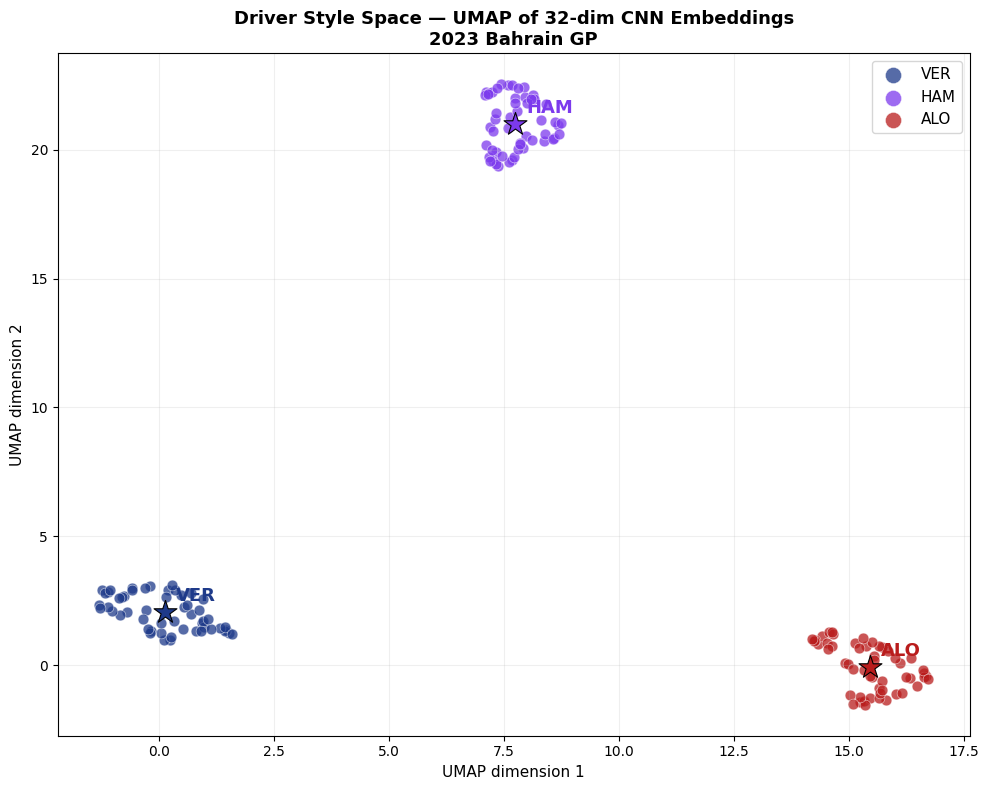

Saved: outputs/figures/04_umap_driver_style_space.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

for driver in DRIVERS:
    mask = drivers == driver
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=COLORS[driver], label=driver,
        s=60, alpha=0.75, edgecolors='white', linewidths=0.4
    )
    # Mark cluster centroid
    cx, cy = X_2d[mask, 0].mean(), X_2d[mask, 1].mean()
    ax.scatter(cx, cy, c=COLORS[driver], s=300, marker='*',
               edgecolors='black', linewidths=0.8, zorder=5)
    ax.annotate(driver, (cx, cy), fontsize=13, fontweight='bold',
                color=COLORS[driver], xytext=(8, 8),
                textcoords='offset points')

ax.set_title(
    'Driver Style Space — UMAP of 32-dim CNN Embeddings\n2023 Bahrain GP',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('UMAP dimension 1', fontsize=11)
ax.set_ylabel('UMAP dimension 2', fontsize=11)
ax.legend(fontsize=11, markerscale=1.5)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '04_umap_driver_style_space.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/04_umap_driver_style_space.png')

## 4. Lap number colored — does style drift across the race?

Color each dot by lap number instead of driver.
If early laps and late laps cluster separately within a driver,
the CNN is also picking up tire degradation signals.

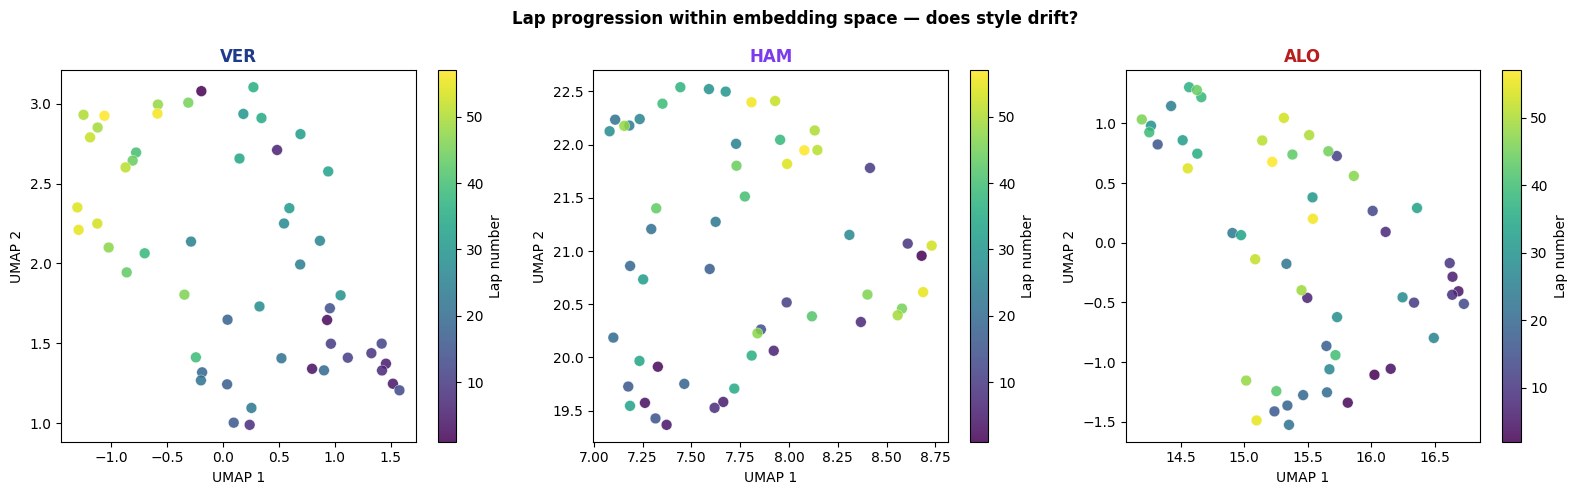

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, driver in zip(axes, DRIVERS):
    mask = drivers == driver
    sc = ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=laps[mask], cmap='viridis',
        s=60, alpha=0.85, edgecolors='white', linewidths=0.3
    )
    plt.colorbar(sc, ax=ax, label='Lap number')
    ax.set_title(driver, fontsize=12, fontweight='bold', color=COLORS[driver])
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

fig.suptitle('Lap progression within embedding space — does style drift?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '04_umap_lap_progression.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Cluster separation metric — quantify how well drivers cluster

Visual inspection is nice but we want a number.
Silhouette score: -1 (bad) to +1 (perfect). 
Measures how much closer each point is to its own cluster vs other clusters.
We compute it in both 32D and 2D.

In [7]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_int = le.fit_transform(drivers)

sil_32d = silhouette_score(X_embed, y_int, metric='euclidean')
sil_2d  = silhouette_score(X_2d,    y_int, metric='euclidean')

print(f'Silhouette score (32D embeddings): {sil_32d:.4f}')
print(f'Silhouette score (2D UMAP):        {sil_2d:.4f}')
print()
print('Interpretation:')
print('  > 0.5  → strong cluster separation (drivers are very distinct)')
print('  0.2–0.5 → moderate separation')
print('  < 0.2  → clusters overlap (drivers look similar to the CNN)')

Silhouette score (32D embeddings): 0.8394
Silhouette score (2D UMAP):        0.9170

Interpretation:
  > 0.5  → strong cluster separation (drivers are very distinct)
  0.2–0.5 → moderate separation
  < 0.2  → clusters overlap (drivers look similar to the CNN)


## 6. Intra vs inter cluster distances

For each driver: mean distance to own laps vs mean distance to other drivers' laps.
Good fingerprinting = small intra-distance, large inter-distance.

In [8]:
from sklearn.metrics import pairwise_distances

dist_matrix = pairwise_distances(X_embed, metric='euclidean')

print(f'{"Driver":<8} {"Intra-dist (mean)":>20} {"Inter-dist (mean)":>20} {"Ratio (inter/intra)":>22}')
print('-' * 72)

for driver in DRIVERS:
    mask_self  = drivers == driver
    mask_other = drivers != driver

    intra = dist_matrix[np.ix_(mask_self, mask_self)]
    inter = dist_matrix[np.ix_(mask_self, mask_other)]

    mean_intra = intra[intra > 0].mean()  # exclude self-distance (0)
    mean_inter = inter.mean()
    ratio      = mean_inter / mean_intra

    print(f'{driver:<8} {mean_intra:>20.4f} {mean_inter:>20.4f} {ratio:>22.4f}')

print()
print('Ratio > 1 means inter-driver distance > intra-driver distance → good fingerprinting')

Driver      Intra-dist (mean)    Inter-dist (mean)    Ratio (inter/intra)
------------------------------------------------------------------------
VER                    1.0966               9.0890                 8.2881
HAM                    1.4153               7.8311                 5.5333
ALO                    0.9018               7.8669                 8.7234

Ratio > 1 means inter-driver distance > intra-driver distance → good fingerprinting


---
## Milestone 4 complete ✓

You now have:
- A trained 1D-CNN encoder producing 32-dim lap embeddings
- UMAP visualization showing driver style space
- Quantitative cluster separation metrics (silhouette score + intra/inter distances)

**Project core is complete.** Next step: README + Streamlit demo.